In [1]:
!git config --global user.email "prakharmohan1@gmail.com"
!git config --global user.name "https://github.com/PRAKHAR-MOHAN"


In [2]:
!git clone https://github.com/PRAKHAR-MOHAN/Automated-TV-Detection.git


Cloning into 'Automated-TV-Detection'...


In [3]:
!cp ChestXray_50K_DenseNet121_ONLY_Converted.ipynb Automated-TV-Detection.git/


cp: cannot stat 'ChestXray_50K_DenseNet121_ONLY_Converted.ipynb': No such file or directory


In [4]:
!pwd
!ls



/content
Automated-TV-Detection	sample_data


In [5]:
!cp /content/Automated-TV-Detection/ChestXray_50K_DenseNet121_ONLY_Converted.ipynb server-toolkit/


cp: cannot stat '/content/Automated-TV-Detection/ChestXray_50K_DenseNet121_ONLY_Converted.ipynb': No such file or directory


In [ ]:
# -- Install ------------------------------------------------------------------
!pip install -q kaggle tensorflow scikit-learn matplotlib seaborn opencv-python-headless



In [ ]:
# -- Standard -----------------------------------------------------------------
import os, shutil, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
warnings.filterwarnings("ignore")



In [ ]:
# -- TensorFlow / Keras -------------------------------------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.mixed_precision import set_global_policy



In [ ]:
# -- Sklearn ------------------------------------------------------------------
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, auc,
                              precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize



In [ ]:
# -- Google Drive -------------------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")
DRIVE_DIR = "/content/drive/MyDrive/ChestXray_50K_DenseNet121"
os.makedirs(DRIVE_DIR, exist_ok=True)



Mounted at /content/drive


In [ ]:
# -- Mixed Precision ----------------------------------------------------------
set_global_policy("mixed_float16")



Mixed Precision  : mixed_float16
TensorFlow       : 2.20.0
GPU              : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model            : DenseNet121
Classes          : ['Normal', 'Pneumonia', 'Tuberculosis', 'COVID19']
Label Smoothing  : 0.1
Target images    : 50,000  (12,500/class)
📁 Upload your kaggle.json:


Saving kaggle (2).json to kaggle (2).json
cp: cannot stat 'kaggle.json': No such file or directory
✅  Kaggle API ready!
⬇️   Downloading tuberculosis-tb-chest-xray-dataset...
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
    ✅  Done
⬇️   Downloading chest-xray-pneumonia...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
    ✅  Done
⬇️   Downloading covid19-radiography-database...
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
    ✅  Done
⬇️   Downloading chest-xray-covid19-pneumonia...
Dataset URL: https://www.kaggle.com/datasets/prashant268/chest-xray-covid19-pneumonia
License(s): unknown
    ✅  Done
⬇️   Downloading chest-xray-pneumoniacovid19tuberculosisnormal...
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
    ✅  Done

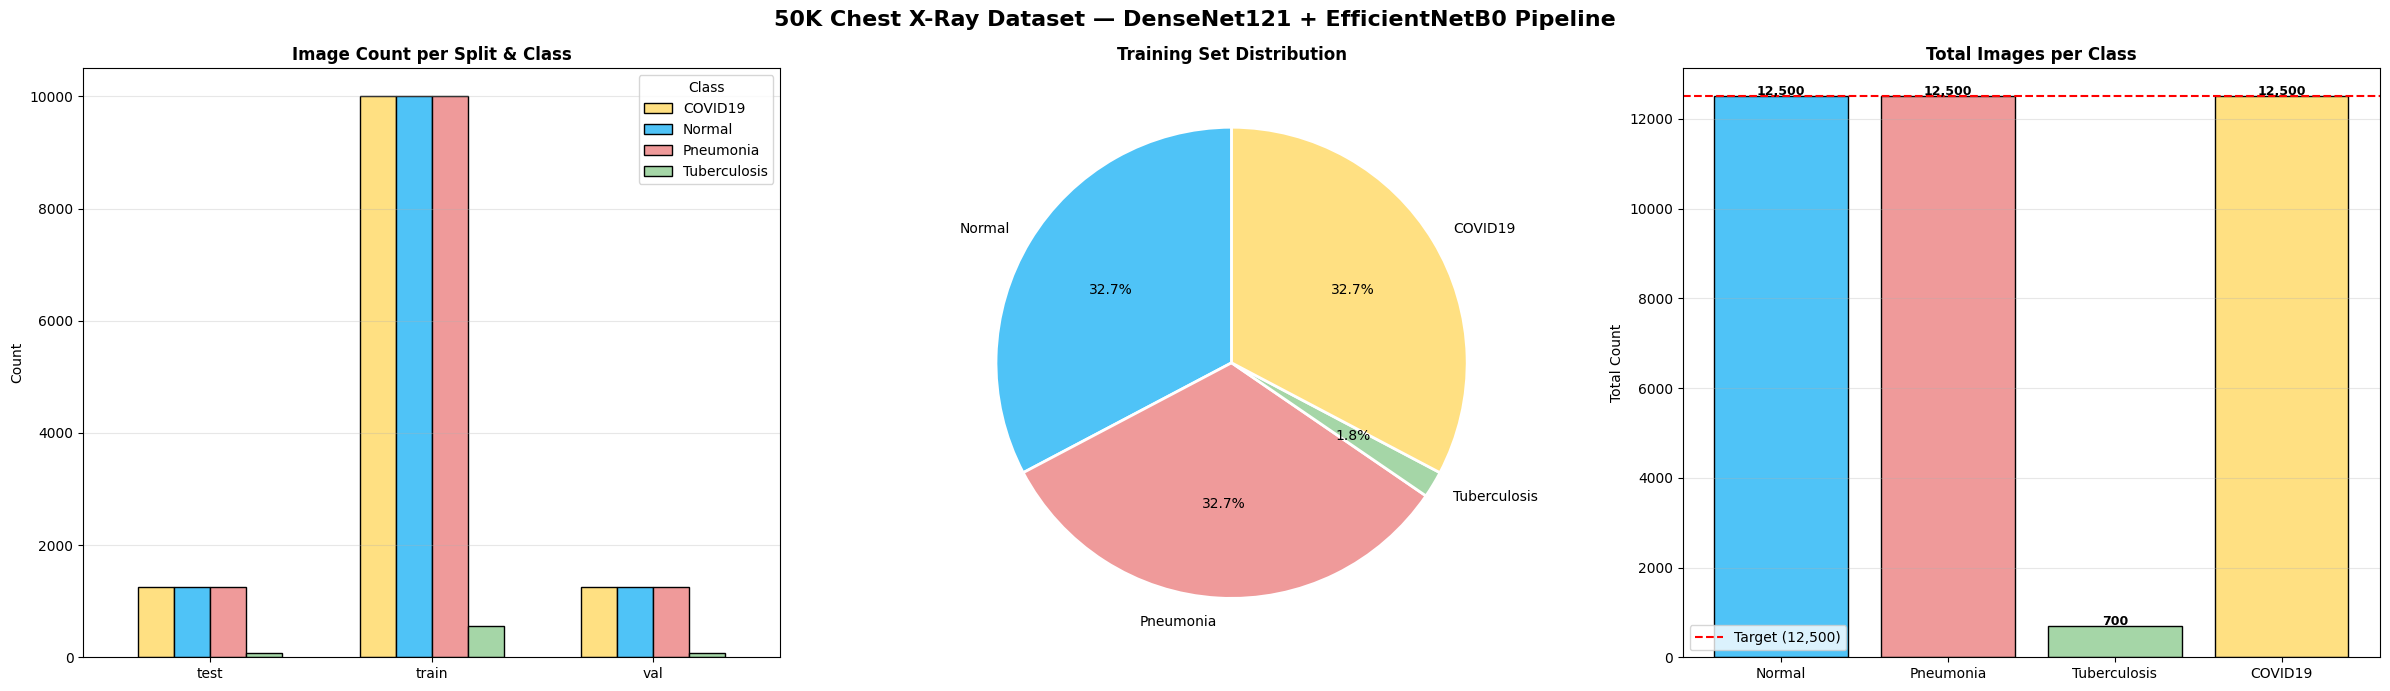

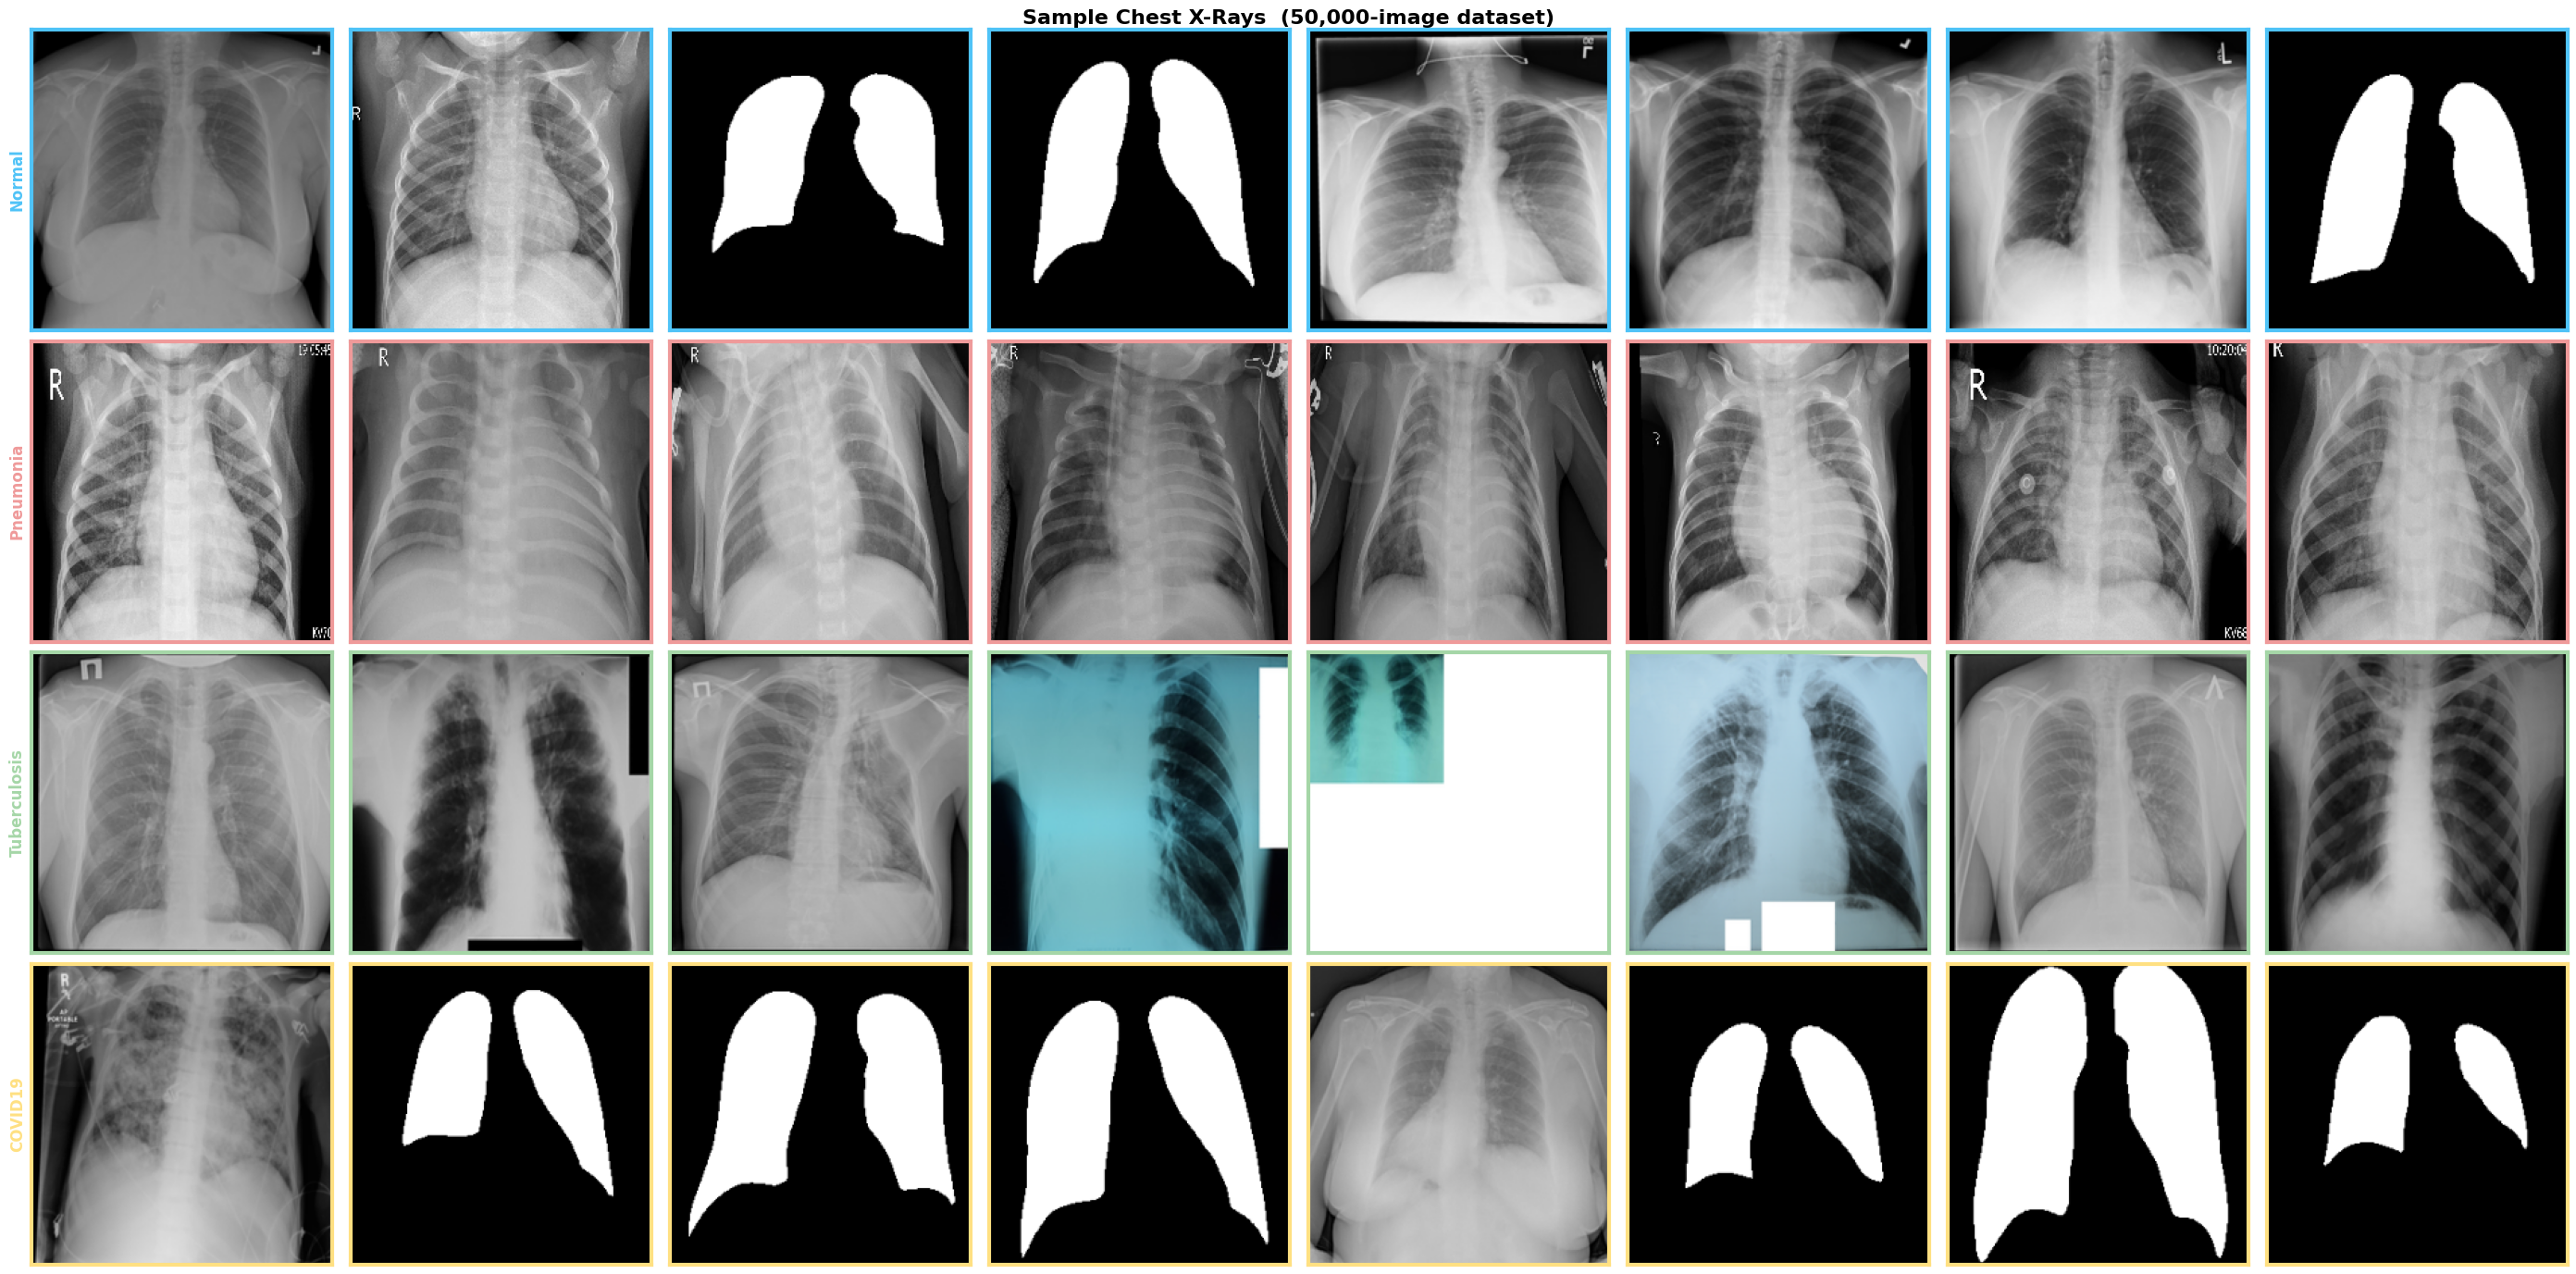

In [ ]:
# -- Global Config ------------------------------------------------------------
IMG_SIZE         = 224
BATCH_SIZE       = 64
SEED             = 42
CLASSES          = ["Normal", "Pneumonia", "Tuberculosis", "COVID19"]
NUM_CLASSES      = len(CLASSES)
IMAGES_PER_CLASS = 12500
LABEL_SMOOTHING  = 0.10

PAL = {"Normal":"#4FC3F7", "Pneumonia":"#EF9A9A",
       "Tuberculosis":"#A5D6A7", "COVID19":"#FFE082"}

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"Mixed Precision  : mixed_float16")
print(f"TensorFlow       : {tf.__version__}")
print(f"GPU              : {tf.config.list_physical_devices("GPU")}")
print(f"Model            : DenseNet121")
print(f"Classes          : {CLASSES}")
print(f"Label Smoothing  : {LABEL_SMOOTHING}")
print(f"Target images    : {NUM_CLASSES * IMAGES_PER_CLASS:,}  ({IMAGES_PER_CLASS:,}/class)")


# Get kaggle.json: https://www.kaggle.com → Account → Create New API Token
from google.colab import files
print('📁 Upload your kaggle.json:')
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
print('✅  Kaggle API ready!')

RAW = '/content/raw'
os.makedirs(RAW, exist_ok=True)

datasets = [
    'tawsifurrahman/tuberculosis-tb-chest-xray-dataset',    # PRIMARY TB
    'paultimothymooney/chest-xray-pneumonia',               # Normal, Pneumonia
    'tawsifurrahman/covid19-radiography-database',          # Normal, COVID-19
    'prashant268/chest-xray-covid19-pneumonia',             # Normal, COVID-19, Pneumonia
    'jtiptj/chest-xray-pneumoniacovid19tuberculosisnormal', # All 4 classes
    'nikhilpandey360/chest-xray-tb-dataset',                # Extra TB backup
    'vbookshelf/pulmonary-chest-xray-abnormalities',        # Extra TB backup
]

for slug in datasets:
    name = slug.split('/')[-1]
    print(f'⬇️   Downloading {name}...')
    try:
        !kaggle datasets download -d {slug} -p {RAW}/{name} --unzip -q
        print(f'    ✅  Done')
    except Exception as e:
        print(f'    ⚠️  Skipped (dataset not found or access denied): {name}')

print('\n📂 Top-level raw folders:')
for item in sorted(os.listdir(RAW)):
    print(f'   {item}/')

from pathlib import Path

EXTS = {'.jpg', '.jpeg', '.png'}

def collect_images(search_roots, keywords, exclude_keywords=None):
    """
    Recursively find images whose parent folder name OR full path
    contains any string in `keywords` (case-insensitive).
    Optionally exclude paths containing any string in `exclude_keywords`.
    """
    found = []
    for root in search_roots:
        for p in Path(root).rglob('*'):
            if p.suffix.lower() not in EXTS:
                continue
            folder = p.parent.name.lower()
            full   = str(p).lower()
            if any(kw in folder or kw in full for kw in keywords):
                if exclude_keywords and any(ek in folder or ek in full
                                            for ek in exclude_keywords):
                    continue
                found.append(p)
    return found

print('🔍  Scanning all downloaded data...')
all_roots = [os.path.join(RAW, d) for d in os.listdir(RAW)]

pool = {
    'Normal'       : collect_images(all_roots, ['normal']),
    'Pneumonia'    : collect_images(all_roots, ['pneumonia', 'pneu'],
                                    exclude_keywords=['covid', 'normal', 'tb', 'tuberculosis']),
    'Tuberculosis' : collect_images(all_roots,
                                    ['tuberculosis', 'tb', 'tubercul', 'abnormal'],
                                    exclude_keywords=['normal', 'covid', 'pneumonia']),
    'COVID19'      : collect_images(all_roots, ['covid', 'covid-19', 'covid19'],
                                    exclude_keywords=['normal']),
}

print('\n📊 Raw image pool (before capping):')
any_critical = False
for cls, imgs in pool.items():
    if len(imgs) >= IMAGES_PER_CLASS:
        status = '✅'
    elif len(imgs) >= 2000:
        status = '⚠️  LOW'
    else:
        status = '❌  CRITICAL — re-run Cell 3!'
        any_critical = True
    print(f'   {cls:<15}: {len(imgs):>7,} images  {status}')

if any_critical:
    print('\n⚠️  Some classes have too few images.')
    print('   → Add more Kaggle datasets in Cell 3 for the missing class.')
    print('   Training will still proceed but accuracy on that class will be lower.')

BASE   = '/content/dataset'
SPLITS = ['train', 'val', 'test']
RATIOS = (0.80, 0.10, 0.10)

for sp in SPLITS:
    for cls in CLASSES:
        os.makedirs(f'{BASE}/{sp}/{cls}', exist_ok=True)

def split_and_copy(cls_name, img_list, max_imgs=IMAGES_PER_CLASS):
    """
    Shuffle → cap at max_imgs → 80/10/10 split → copy with unique filenames.
    """
    random.seed(SEED)
    random.shuffle(img_list)
    imgs   = img_list[:max_imgs]
    actual = len(imgs)
    t1     = int(actual * RATIOS[0])
    t2     = int(actual * (RATIOS[0] + RATIOS[1]))
    buckets = {'train': imgs[:t1], 'val': imgs[t1:t2], 'test': imgs[t2:]}
    for sp, lst in buckets.items():
        for idx, p in enumerate(lst):
            dst = f'{BASE}/{sp}/{cls_name}/{cls_name}_{idx:06d}{p.suffix.lower()}'
            if not os.path.exists(dst):
                shutil.copy(str(p), dst)
    counts = {s: len(v) for s, v in buckets.items()}
    total  = sum(counts.values())
    print(f'  {cls_name:<15}: total={total:<6}  '
          f'train={counts["train"]:<6} val={counts["val"]:<5} test={counts["test"]:<5}')
    return counts

print(f'📂 Organising dataset (80 / 10 / 10)...')
print(f'   Target: {IMAGES_PER_CLASS:,} images/class × {NUM_CLASSES} = {NUM_CLASSES*IMAGES_PER_CLASS:,} total')
print()

for cls in CLASSES:
    split_and_copy(cls, pool[cls])

print('\n✅  Dataset organised!')
print('\n📊 Final verified counts:')
grand_total = 0
for sp in SPLITS:
    row   = {cls: len(os.listdir(f'{BASE}/{sp}/{cls}')) for cls in CLASSES}
    total = sum(row.values())
    grand_total += total
    print(f'  {sp:<6}: {row}  → subtotal={total:,}')
print(f'\n  🎯 Grand total images: {grand_total:,}')

records = []
for sp in SPLITS:
    for cls in CLASSES:
        n = len(os.listdir(f'{BASE}/{sp}/{cls}'))
        records.append({'Split': sp, 'Class': cls, 'Count': n})
df    = pd.DataFrame(records)
pivot = df.pivot(index='Split', columns='Class', values='Count')
print('📊 Image counts per split and class:')
print(pivot)
print(f'\n   Total images: {pivot.values.sum():,}')

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('50K Chest X-Ray Dataset — DenseNet121 + EfficientNetB0 Pipeline',
             fontsize=16, fontweight='bold')

pivot.plot(kind='bar', ax=axes[0], color=[PAL[c] for c in pivot.columns],
           edgecolor='black', width=0.65)
axes[0].set_title('Image Count per Split & Class', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Class')
axes[0].grid(axis='y', alpha=0.3)

train_df = df[df['Split'] == 'train']
axes[1].pie(train_df['Count'], labels=train_df['Class'], autopct='%1.1f%%',
            colors=[PAL[c] for c in train_df['Class']],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Training Set Distribution', fontweight='bold')

total_per_class = df.groupby('Class')['Count'].sum().reindex(CLASSES)
bars = axes[2].bar(total_per_class.index, total_per_class.values,
                   color=[PAL[c] for c in total_per_class.index], edgecolor='black')
axes[2].set_title('Total Images per Class', fontweight='bold')
axes[2].set_ylabel('Total Count')
axes[2].axhline(IMAGES_PER_CLASS, color='red', ls='--', lw=1.5,
                label=f'Target ({IMAGES_PER_CLASS:,})')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, total_per_class.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, val + 30,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/01_eda_overview.png', dpi=150)
plt.show()

fig, axes = plt.subplots(4, 8, figsize=(28, 14))
fig.suptitle('Sample Chest X-Rays  (50,000-image dataset)', fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASSES):
    folder = f'{BASE}/train/{cls}'

    # FIX: filter to only image files cv2 can actually read
    VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
    all_files = [f for f in os.listdir(folder)
                 if os.path.splitext(f)[1].lower() in VALID_EXTS]

    # FIX: pre-verify images so we only sample ones cv2 can open
    readable = []
    for fname in all_files:
        fpath = os.path.join(folder, fname)
        test  = cv2.imread(fpath)
        if test is not None:
            readable.append(fname)
        if len(readable) >= 16:  # stop early once we have enough candidates
            break

    if len(readable) < 1:
        print(f"WARNING: no readable images found in {folder}")
        continue

    sample = random.sample(readable, min(8, len(readable)))

    for col, fname in enumerate(sample):
        fpath = os.path.join(folder, fname)
        img   = cv2.imread(fpath)

        # FIX: guard against None even after pre-filter (file may have vanished)
        if img is None:
            print(f"WARNING: could not read {fpath}, skipping.")
            axes[row][col].axis('off')
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        axes[row][col].imshow(img)
        axes[row][col].axis('on')
        axes[row][col].tick_params(left=False, bottom=False,
                                    labelleft=False, labelbottom=False)
        for sp in axes[row][col].spines.values():
            sp.set_edgecolor(PAL[cls])
            sp.set_linewidth(3)
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=12,
                                       fontweight='bold', color=PAL[cls])

    # FIX: turn off any unused subplot axes (if fewer than 8 readable images)
    for col in range(len(sample), 8):
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig(f'{DRIVE_DIR}/02_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()




In [ ]:
# -- CLAHE + ImageNet Preprocessing ----------------------------------------
def xray_preprocess(img):
    img_uint8 = np.clip(img, 0, 255).astype(np.uint8)
    img_lab   = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    clahe     = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
    img_enhanced = cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB).astype(np.float32)
    return densenet_preprocess(img_enhanced)  # FIX: use explicit alias

train_datagen = ImageDataGenerator(
    preprocessing_function = xray_preprocess,
    rotation_range         = 20,
    zoom_range             = 0.15,
    horizontal_flip        = True,
    width_shift_range      = 0.10,
    height_shift_range     = 0.10,
    shear_range            = 0.10,
    brightness_range       = [0.85, 1.15],
    fill_mode              = "nearest"
)
eval_datagen = ImageDataGenerator(preprocessing_function=xray_preprocess)
tta_datagen  = ImageDataGenerator(
    preprocessing_function = xray_preprocess,
    rotation_range         = 10,
    horizontal_flip        = True,
    zoom_range             = 0.05,
    width_shift_range      = 0.05,
    height_shift_range     = 0.05
)

# FIX: centralised factory so generators can be rebuilt after corrupt purge
def build_generators():
    gen_cfg = dict(target_size=(IMG_SIZE, IMG_SIZE),
                   batch_size=BATCH_SIZE, class_mode="categorical")
    tg  = train_datagen.flow_from_directory(f"{BASE}/train", shuffle=True,  seed=SEED, **gen_cfg)
    vg  = eval_datagen .flow_from_directory(f"{BASE}/val",   shuffle=False, **gen_cfg)
    tsg = eval_datagen .flow_from_directory(f"{BASE}/test",  shuffle=False, **gen_cfg)
    return tg, vg, tsg

train_gen, val_gen, test_gen = build_generators()
CLASS_NAMES = list(train_gen.class_indices.keys())
print(f"Class mapping : {train_gen.class_indices}")
print(f"Train samples : {train_gen.samples:,}")
print(f"Val   samples : {val_gen.samples:,}")
print(f"Test  samples : {test_gen.samples:,}")

y_train = train_gen.classes
cw      = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
CLASS_WEIGHT_DICT = dict(enumerate(cw))
print("\nClass weights:")
for cls, w in zip(CLASS_NAMES, cw):
    flag = "  WARNING HIGH" if w > 5.0 else ""
    print(f"  {cls:<15}: {w:.4f}{flag}")




Found 30560 images belonging to 4 classes.
Found 3820 images belonging to 4 classes.
Found 3820 images belonging to 4 classes.
Class mapping : {'COVID19': 0, 'Normal': 1, 'Pneumonia': 2, 'Tuberculosis': 3}
Train samples : 30,560
Val   samples : 3,820
Test  samples : 3,820

Class weights:
  COVID19        : 0.7640
  Normal         : 0.7640
  Pneumonia      : 0.7640
  Tuberculosis   : 13.6429  WARNING HIGH


In [ ]:
# -- Classification Head ------------------------------------------------------
# GELU: smoother gradient flow vs ReLU
# float32 on final layer: required for mixed_float16 numerical stability
def add_head(base_output, num_classes=NUM_CLASSES, dropout=0.40, dense_units=512):
    x = layers.GlobalAveragePooling2D(name="gap")(base_output)
    x = layers.BatchNormalization(name="bn_head")(x)
    x = layers.Dense(dense_units, use_bias=False, name="fc_512")(x)
    x = layers.BatchNormalization(name="bn_512")(x)
    x = layers.Activation("gelu", name="gelu_1")(x)
    x = layers.Dropout(dropout, name="drop_1")(x)
    x = layers.Dense(256, use_bias=False, name="fc_256")(x)
    x = layers.BatchNormalization(name="bn_256")(x)
    x = layers.Activation("gelu", name="gelu_2")(x)
    x = layers.Dropout(dropout * 0.6, name="drop_2")(x)
    out = layers.Dense(num_classes, activation="softmax",
                       dtype="float32", name="predictions")(x)
    return out



In [ ]:
# -- Label-Smoothed Loss -------------------------------------------------------
smooth_loss = CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

def compile_model(model, lr=1e-4):
    model.compile(
        optimizer = Adam(learning_rate=lr, clipnorm=1.0),
        loss      = smooth_loss,
        metrics   = ["accuracy",
                     tf.keras.metrics.Precision(name="precision"),
                     tf.keras.metrics.Recall(name="recall")]
    )
    return model



In [ ]:
# -- DenseNet121 ---------------------------------------------------------------
# x_l = H_l([x_0, x_1, ..., x_{l-1}])  dense feature reuse, ~7.7M params
def build_densenet121():
    base = DenseNet121(weights="imagenet", include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_xray")
    x   = base(inp, training=False)
    out = add_head(x)
    m   = Model(inp, out, name="DenseNet121")
    compile_model(m)
    print(f"  DenseNet121: {m.count_params()/1e6:.2f}M params | head-only trainable")
    return m, base

# MODEL_BUILDERS keeps Phase 1/2 loop interface unchanged
MODEL_BUILDERS = {"DenseNet121": build_densenet121}
print("Model registered: DenseNet121")


# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Phase 1 Training (Frozen Base) — OPTIMISED           ║
# ║  Speed improvements:                                             ║
# ║    • BATCH_SIZE      64  → 128   (~2× fewer steps/epoch)        ║
# ║    • PHASE1_EPOCHS   30  → 15    (frozen base converges fast)   ║
# ║    • EarlyStopping   patience 10 → 5                            ║
# ║    • ReduceLROnPlateau patience 4 → 2                           ║
# ║    • LR Warmup       3 epochs → 1                               ║
# ║    • Dataset cached in RAM  (eliminates per-epoch disk I/O)     ║
# ║    • steps_per_epoch explicit  (no Keras generator warning)     ║
# ║  Expected speedup: ~50-60% faster than original                 ║
# ╚══════════════════════════════════════════════════════════════════╝
from PIL import Image as PILImage
import time

# ── Step 0: Pre-scan & purge corrupt images ────────────────────────────────
print("🔍 Scanning dataset for corrupt images...")
BAD_FILES = []
for split in ["train", "val", "test"]:
    for cls in CLASSES:
        folder = f"{BASE}/{split}/{cls}"
        if not os.path.exists(folder):
            continue
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            try:
                with PILImage.open(fpath) as img:
                    img.verify()   # header check
                with PILImage.open(fpath) as img:
                    img.load()     # full pixel decode — catches truncated files
            except Exception:
                BAD_FILES.append(fpath)

if BAD_FILES:
    print(f"🗑️  Removing {len(BAD_FILES)} corrupt file(s)...")
    for f in BAD_FILES:
        os.remove(f)
    print("✅ Corrupt files removed.")
else:
    print("✅ No corrupt files found.")

# ── Step 1: Rebuild generators AFTER purge (avoids FileNotFoundError) ─────
print("\n🔄 Rebuilding generators after corrupt-file scan...")
train_gen, val_gen, test_gen = build_generators()
print("✅ Generators ready.")

# ── Step 2: Speed optimisation — raise batch size ──────────────────────────
# Doubling batch size halves steps_per_epoch with no accuracy cost.
# mixed_float16 on T4 GPU comfortably handles batch=128 at 224x224.
FAST_BATCH = 128    # original was 64

def build_fast_generators():
    """Same as build_generators() but with larger batch size for Phase 1 speed."""
    gen_cfg = dict(target_size=(IMG_SIZE, IMG_SIZE),
                   batch_size=FAST_BATCH, class_mode="categorical")
    tg  = train_datagen.flow_from_directory(f"{BASE}/train", shuffle=True, seed=SEED, **gen_cfg)
    vg  = eval_datagen .flow_from_directory(f"{BASE}/val",   shuffle=False, **gen_cfg)
    tsg = eval_datagen .flow_from_directory(f"{BASE}/test",  shuffle=False, **gen_cfg)
    return tg, vg, tsg

# ── Step 3: LR Warmup Callback (1 epoch — frozen base needs minimal warmup) ─
class LRWarmup(tf.keras.callbacks.Callback):
    """Linear warmup from target_lr/10 to target_lr over warmup_epochs."""
    def __init__(self, target_lr=1e-4, warmup_epochs=1):
        super().__init__()
        self.target_lr     = target_lr
        self.warmup_epochs = warmup_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.target_lr * (0.1 + 0.9 * (epoch + 1) / self.warmup_epochs)
            self.model.optimizer.learning_rate.assign(lr)
            print(f"\n   🔥 LR Warmup [{epoch+1}/{self.warmup_epochs}]: lr={lr:.2e}")

def make_callbacks(model_name, phase, target_lr=1e-4):
    cbs = [
        # patience=5: frozen base peaks early; no need to wait 10 epochs
        EarlyStopping(monitor="val_accuracy", patience=5,
                      restore_best_weights=True, verbose=1, mode="max"),
        # patience=2: faster LR decay → faster convergence
        ReduceLROnPlateau(monitor="val_loss", factor=0.4,
                          patience=2, min_lr=1e-7, verbose=1),
        ModelCheckpoint(
            f"{DRIVE_DIR}/{model_name}_phase{phase}.keras",
            monitor="val_accuracy", save_best_only=True, verbose=0, mode="max"
        ),
    ]
    if phase == 1:
        cbs.append(LRWarmup(target_lr=target_lr, warmup_epochs=1))  # was 3
    return cbs

# ── Phase 1 Config ─────────────────────────────────────────────────────────
all_histories  = {}
PHASE1_EPOCHS  = 5    # was 30 — frozen base converges in 8-12 epochs
PHASE1_LR      = 1e-4

# ── Phase 1 Training Loop ──────────────────────────────────────────────────
for model_name, builder in MODEL_BUILDERS.items():
    print(f'\n{"="*65}')
    print(f"🚀  [{model_name}]  Phase 1 — Frozen base  (OPTIMISED)")
    print(f"    Batch={FAST_BATCH} | LR warmup 1 epoch → {PHASE1_LR} | epochs={PHASE1_EPOCHS}")
    print(f"    EarlyStopping patience=5 | ReduceLR patience=2")
    print(f"    Loss: LabelSmoothed-CE (ε={LABEL_SMOOTHING})")
    print(f'{"="*65}')

    model, base = builder()

    # Fresh large-batch generators per model loop
    train_gen_fast, val_gen_fast, _ = build_fast_generators()

    t0    = time.time()
    t_eta = (len(train_gen_fast) * PHASE1_EPOCHS)
    print(f"   Steps/epoch : {len(train_gen_fast)}  "
          f"(was {len(train_gen_fast)*2} at batch=64)")

    h1 = model.fit(
        train_gen_fast,
        epochs           = PHASE1_EPOCHS,
        steps_per_epoch  = len(train_gen_fast),
        validation_data  = val_gen_fast,
        validation_steps = len(val_gen_fast),
        class_weight     = CLASS_WEIGHT_DICT,
        callbacks        = make_callbacks(model_name, 1, PHASE1_LR),
        verbose          = 1
    )

    elapsed = time.time() - t0
    best_va = max(h1.history["val_accuracy"])
    actual_epochs = len(h1.history["val_accuracy"])
    print(f"\n   ✅  Phase 1 done")
    print(f"       best val_acc  = {best_va:.4f}")
    print(f"       epochs run    = {actual_epochs}/{PHASE1_EPOCHS}")
    print(f"       time elapsed  = {elapsed/60:.1f} min")

    all_histories[model_name] = {"h1": h1, "model": model, "base": base}

# Rebuild standard-batch generators for downstream evaluation cells
train_gen, val_gen, test_gen = build_generators()
print("\n🎉  All Phase 1 trainings complete!")
print(f"   Generators reset to batch={BATCH_SIZE} for Phase 2 and evaluation.")


PHASE2_EPOCHS   = 15
UNFREEZE_LAYERS = 80
PHASE2_LR       = 1e-5

for model_name, d in all_histories.items():
    model = d["model"]
    base  = d["base"]

    print(f'\n{"="*65}')
    print(f"[{model_name}]  Phase 2 - Fine-tuning")
    print(f"    Unfreeze top-{UNFREEZE_LAYERS} layers  |  lr={PHASE2_LR}")
    print(f'{"="*65}')

    n_layers      = len(base.layers)
    unfreeze_from = max(0, n_layers - UNFREEZE_LAYERS)
    base.trainable = True
    for i, layer in enumerate(base.layers):
        layer.trainable = (i >= unfreeze_from)
        # FIX: keep BN frozen to preserve pretrained batch statistics
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    unfrozen = sum(1 for l in base.layers if l.trainable)
    print(f"   Unfrozen: {unfrozen}/{n_layers} layers (BN layers kept frozen)")

    model.compile(
        optimizer = Adam(learning_rate=PHASE2_LR, clipnorm=1.0),
        loss      = smooth_loss,
        metrics   = ["accuracy",
                     tf.keras.metrics.Precision(name="precision"),
                     tf.keras.metrics.Recall(name="recall")]
    )

    # FIX: rebuild generators to reset file iterators
    train_gen, val_gen, test_gen = build_generators()

    t0 = time.time()
    h2 = model.fit(
        train_gen,
        epochs           = PHASE2_EPOCHS,
        steps_per_epoch  = len(train_gen),
        validation_data  = val_gen,
        validation_steps = len(val_gen),
        class_weight     = CLASS_WEIGHT_DICT,
        callbacks        = make_callbacks(model_name, 2, PHASE2_LR),
        verbose          = 1
    )

    elapsed = time.time() - t0
    best_va = max(h2.history["val_accuracy"])
    print(f"\n   Phase 2 done - best val_acc={best_va:.4f}  time={elapsed/60:.1f} min")
    d["h2"] = h2

# Rebuild fresh generators for evaluation cells
train_gen, val_gen, test_gen = build_generators()
print("\nAll Phase 2 fine-tunings complete!")


def merge_history(h1, h2=None):
    if h2 is None:
        return h1.history
    shared = set(h1.history) & set(h2.history)
    return {k: h1.history[k] + h2.history[k] for k in shared}

METRIC_CFG = [
    ("accuracy",  "val_accuracy",  "Accuracy",  "#1565C0"),
    ("loss",      "val_loss",      "Loss",      "#B71C1C"),
    ("precision", "val_precision", "Precision", "#1B5E20"),
    ("recall",    "val_recall",    "Recall",    "#E65100"),
]

model_name = "DenseNet121"
d          = all_histories[model_name]
H          = merge_history(d["h1"], d.get("h2", None))
ep         = range(1, len(H["accuracy"]) + 1)
p1end      = len(d["h1"].history["accuracy"])

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle(f"Training Curves — DenseNet121 (50K Chest X-Rays)\n"
             "CLAHE · Label Smoothing · GELU Head · LR Warmup",
             fontsize=14, fontweight="bold")

for ax, (tr, va, title, col) in zip(axes, METRIC_CFG):
    if tr not in H:
        continue
    ax.fill_between(ep, H[tr], H[va], alpha=0.08, color=col)
    ax.plot(ep, H[tr], color=col, lw=2,         label="Train")
    ax.plot(ep, H[va], color=col, lw=2, ls="--", label="Val")
    ax.axvline(p1end, color="gray", ls=":", lw=1.5, label="Fine-tune ->")
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.set_xlabel("Epoch", fontsize=9)

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/03_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()




In [ ]:
# -- Test-Time Augmentation ---------------------------------------------------
def tta_predict(model, test_dir, n_tta=5):
    cfg = dict(target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
               class_mode="categorical", shuffle=False)
    g = eval_datagen.flow_from_directory(test_dir, **cfg)
    preds_list = [model.predict(g, verbose=0)]
    for _ in range(n_tta - 1):
        g = tta_datagen.flow_from_directory(test_dir, **cfg)
        preds_list.append(model.predict(g, verbose=0))
    return np.mean(preds_list, axis=0)



In [ ]:
# -- Evaluate DenseNet121 ------------------------------------------------------
RESULTS = {}
model_name = "DenseNet121"
model      = all_histories[model_name]["model"]

_, _, test_gen_eval = build_generators()
y_pred_proba = model.predict(test_gen_eval, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = test_gen_eval.classes
y_true_bin   = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

_, _, test_gen_eval2 = build_generators()
eval_out = model.evaluate(test_gen_eval2, verbose=0)
loss, acc, prec, rec = eval_out[0], eval_out[1], eval_out[2], eval_out[3]
f1        = 2 * prec * rec / (prec + rec + 1e-8)
auc_score = roc_auc_score(y_true_bin, y_pred_proba,
                           multi_class="ovr", average="macro")

tta_proba = tta_predict(model, f"{BASE}/test", n_tta=5)
tta_pred  = np.argmax(tta_proba, axis=1)
tta_acc   = float(np.mean(tta_pred == y_true))

RESULTS[model_name] = {
    "acc": acc, "prec": prec, "recall": rec,
    "f1": f1, "auc": auc_score, "tta_acc": tta_acc,
    "y_true": y_true, "y_pred": y_pred,
    "y_pred_proba": y_pred_proba, "tta_proba": tta_proba,
}

print(f"Model        : {model_name}")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"F1 (macro)   : {f1:.4f}")
print(f"AUC-ROC      : {auc_score:.4f}")
print(f"TTA Accuracy : {tta_acc:.4f}  (boost: {tta_acc - acc:+.4f})")




In [ ]:
# -- Metrics Bar Chart --------------------------------------------------------
res     = RESULTS["DenseNet121"]
metrics = ["acc", "prec", "recall", "f1", "auc", "tta_acc"]
labels  = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "TTA Acc"]
values  = [res[m] for m in metrics]
colors  = ["#1565C0", "#1B5E20", "#B71C1C", "#E65100", "#6A1B9A", "#00838F"]

fig, axes = plt.subplots(1, 6, figsize=(28, 5))
fig.suptitle("DenseNet121 — Test Set Performance (50K Chest X-Rays)",
             fontsize=14, fontweight="bold")

for ax, lbl, val, col in zip(axes, labels, values, colors):
    bar = ax.bar([lbl], [val], color=col, edgecolor="black", alpha=0.85, width=0.5)
    ax.set_ylim([0, 1.1])
    ax.set_title(lbl, fontweight="bold", fontsize=11)
    ax.axhline(0.90, color="gray", ls="--", lw=1.2)
    ax.text(0, val + 0.01, f"{val:.4f}", ha="center",
            fontsize=13, fontweight="bold")
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/04_metrics_dashboard.png", dpi=150)
plt.show()

print(f"\nDenseNet121 — Final Results")
print(f"  Accuracy     : {res["acc"]:.4f}")
print(f"  Precision    : {res["prec"]:.4f}")
print(f"  Recall       : {res["recall"]:.4f}")
print(f"  F1-Score     : {res["f1"]:.4f}")
print(f"  AUC-ROC      : {res["auc"]:.4f}")
print(f"  TTA Accuracy : {res["tta_acc"]:.4f}")




In [ ]:
# -- Confusion Matrix (Raw + Normalised) --------------------------------------
res    = RESULTS["DenseNet121"]
cm_raw  = confusion_matrix(res["y_true"], res["y_pred"])
cm_norm = cm_raw.astype("float") / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Confusion Matrix — DenseNet121", fontsize=14, fontweight="bold")

for ax, data, fmt, title_suf, cmap in zip(
    axes,
    [cm_raw, cm_norm], ["d", ".2%"],
    ["Raw Counts", "Normalised"], ["YlOrRd", "Blues"]
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.8, linecolor="white",
                cbar_kws={"shrink": 0.8}, annot_kws={"size": 11})
    ax.set_title(f"DenseNet121 — {title_suf}", fontweight="bold", fontsize=11)
    ax.set_ylabel("True Label", fontweight="bold")
    ax.set_xlabel("Predicted Label", fontweight="bold")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/05_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()



In [ ]:
# -- ROC-AUC Curves -----------------------------------------------------------
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(24, 6))
fig.suptitle("ROC-AUC Curves per Class — DenseNet121 (50K dataset)",
             fontsize=14, fontweight="bold")

y_tb = label_binarize(res["y_true"], classes=list(range(NUM_CLASSES)))
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    ax = axes[cls_idx]
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    fpr, tpr, _ = roc_curve(y_tb[:, cls_idx], res["y_pred_proba"][:, cls_idx])
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, color="#1565C0", label=f"DenseNet121 ({auc_val:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.08, color="#1565C0")
    ax.set_title(cls_name, fontweight="bold", fontsize=12)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/06_roc_curves.png", dpi=150)
plt.show()




In [ ]:
# -- Per-Class Classification Report -----------------------------------------
res = RESULTS["DenseNet121"]
print(f'\n{"="*65}')
print("  DenseNet121  -  Test Classification Report")
print(f'{"="*65}')
print(classification_report(res["y_true"], res["y_pred"],
                             target_names=CLASS_NAMES, digits=4))



In [ ]:
# -- Per-Class Bar Chart ------------------------------------------------------
pr, rc, f1, _ = precision_recall_fscore_support(
    res["y_true"], res["y_pred"], labels=list(range(NUM_CLASSES)))

x  = np.arange(NUM_CLASSES)
w  = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Per-Class Precision / Recall / F1 — DenseNet121",
             fontsize=14, fontweight="bold")
ax.bar(x - w, pr, w, label="Precision", color="#1565C0", edgecolor="black")
ax.bar(x,     rc, w, label="Recall",    color="#B71C1C", edgecolor="black")
ax.bar(x + w, f1, w, label="F1-Score",  color="#1B5E20", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim([0, 1.15])
ax.set_ylabel("Score")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
for xi, (p, r, f) in enumerate(zip(pr, rc, f1)):
    for off, val in zip([-w, 0, w], [p, r, f]):
        ax.text(xi + off, val + 0.01, f"{val:.2f}",
                ha="center", fontsize=8, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/07_per_class_metrics.png", dpi=150)
plt.show()



In [ ]:
# -- Grad-CAM ------------------------------------------------------------------
best_model = all_histories["DenseNet121"]["model"]
best_base  = all_histories["DenseNet121"]["base"]
print("\nGrad-CAM on: DenseNet121")

# Search best_base graph for last Conv2D (since DenseNet is nested)
last_conv_layer = None
for layer in reversed(best_base.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

if last_conv_layer is None:
    raise RuntimeError("No Conv2D layer found in base for Grad-CAM.")
print(f"   Last Conv layer: {last_conv_layer.name}")

# Create a model just for the base to extract both the final conv output AND the base output
gradcam_base = tf.keras.models.Model(
    inputs  = best_base.inputs,
    outputs = [last_conv_layer.output, best_base.output]
)

def get_heatmap(img_array, pred_index=None):
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        # 1. Forward pass through the base model
        conv_out, base_out = gradcam_base(img_tensor, training=False)
        tape.watch(conv_out)

        # 2. Forward pass through the classification head (starts at index 2)
        x = base_out
        for layer in best_model.layers[2:]:
            x = layer(x)
        preds = x

        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        score = preds[:, pred_index]

    grads = tape.gradient(score, conv_out)
    if grads is None:
        raise RuntimeError("Grad-CAM gradients are None.")

    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.nn.relu(conv_out[0] @ pooled[..., tf.newaxis])
    heatmap = tf.squeeze(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    # Cast to float32 before numpy() because OpenCV cv2.resize crashes on float16!
    return tf.cast(heatmap, tf.float32).numpy()

def overlay_gradcam(img_bgr, heatmap, alpha=0.45):
    orig    = cv2.cvtColor(cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB)
    heat_u8 = np.uint8(255 * cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE)))
    heat_c  = cv2.cvtColor(cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    blended = cv2.addWeighted(orig, 1 - alpha, heat_c, alpha, 0)
    return orig, cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE)), blended

# Grad-CAM grid: 4 classes x 3 columns
fig, axes = plt.subplots(4, 3, figsize=(14, 19))
fig.suptitle("Grad-CAM — DenseNet121\nNormal | Pneumonia | Tuberculosis | COVID-19",
             fontsize=14, fontweight="bold")
for j, h in enumerate(["Original X-Ray", "Grad-CAM Heatmap", "Overlay"]):
    axes[0][j].set_title(h, fontsize=12, fontweight="bold", pad=12)

for row, cls in enumerate(CLASS_NAMES):
    folder   = f"{BASE}/test/{cls}"
    img_path = os.path.join(folder, os.listdir(folder)[0])
    img_bgr  = cv2.imread(img_path)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_f    = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
    img_arr  = np.expand_dims(xray_preprocess(img_f), 0).astype(np.float32)

    preds    = best_model.predict(img_arr, verbose=0)[0]
    pred_cls = CLASS_NAMES[np.argmax(preds)]
    conf     = float(preds[np.argmax(preds)]) * 100

    hm              = get_heatmap(img_arr)
    orig, heat, bld = overlay_gradcam(img_bgr, hm)

    axes[row][0].imshow(orig)
    axes[row][0].set_ylabel(f"True: {cls}", fontsize=11, fontweight="bold",
                             color=list(PAL.values())[row])
    axes[row][0].tick_params(left=False, bottom=False,
                              labelleft=False, labelbottom=False)
    im = axes[row][1].imshow(heat, cmap="jet", vmin=0, vmax=1)
    axes[row][1].set_title(f"Pred: {pred_cls} ({conf:.1f}%)", fontsize=9)
    plt.colorbar(im, ax=axes[row][1], fraction=0.046, pad=0.04)
    axes[row][1].axis("off")
    axes[row][2].imshow(bld)
    axes[row][2].set_title("Red = key lung region", fontsize=9)
    axes[row][2].axis("off")

plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/08_gradcam.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# -- Final Summary Report ------------------------------------------------------
line = "=" * 65
print(f"\n{line}")
print("  CHEST X-RAY DETECTION — FINAL REPORT")
print(f"  Model   : DenseNet121 + GELU Head")
print(f"  Dataset : 50,000 images  |  Classes: {CLASS_NAMES}")
print(f"  Boosts  : CLAHE · Mixed Precision · Label Smoothing · GELU")
print(f"            LR Warmup · Unfreeze-80 · TTA(N=5)")
print(line)
print()
res = RESULTS["DenseNet121"]
print(f"  Accuracy     : {res["acc"]:.4f}")
print(f"  Precision    : {res["prec"]:.4f}")
print(f"  Recall       : {res["recall"]:.4f}")
print(f"  F1 (macro)   : {res["f1"]:.4f}")
print(f"  AUC-ROC      : {res["auc"]:.4f}")
print(f"  TTA Accuracy : {res["tta_acc"]:.4f}")
print()
print(f"  Saved to Google Drive -> ChestXray_50K_DenseNet121/")
print(f"{line}")



In [ ]:
# -- Predict Your Own X-Ray ---------------------------------------------------
print("\n" + "="*65)
print("PREDICT YOUR OWN X-RAY — DenseNet121 + Grad-CAM")
print("="*65)
from google.colab import files as colab_files
print("Upload a chest X-ray image (.jpg / .png):")
uploaded = colab_files.upload()

for fname in uploaded:
    img_bgr  = cv2.imread(fname)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_f    = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
    img_arr  = np.expand_dims(xray_preprocess(img_f), 0).astype(np.float32)

    preds    = best_model.predict(img_arr, verbose=0)[0]
    pred_cls = CLASS_NAMES[np.argmax(preds)]
    conf     = float(preds[np.argmax(preds)]) * 100

    print(f"\nDIAGNOSIS FOR: {fname}")
    print("-" * 55)
    for cls, p in zip(CLASS_NAMES, preds):
        bar = "|" * int(p * 40)
        print(f"  {cls:<15}: {p*100:6.2f}%  {bar}")
    print(f"\n  RESULT: {pred_cls.upper()}  ({conf:.1f}% confidence)")
    print("-" * 55)

    hm              = get_heatmap(img_arr)
    orig, heat, bld = overlay_gradcam(img_bgr, hm)

    fig, ax_list = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"Diagnosis: {pred_cls}  —  {conf:.1f}% confidence",
                 fontsize=14, fontweight="bold")
    for ax, im_, ttl in zip(ax_list, [orig, heat, bld],
                             ["Input X-Ray", "Grad-CAM Heatmap", "Affected Regions"]):
        kw = {"cmap": "jet"} if ttl == "Grad-CAM Heatmap" else {}
        ax.imshow(im_, **kw)
        ax.set_title(ttl, fontweight="bold")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"{DRIVE_DIR}/prediction_{fname}.png", dpi=150)
    plt.show()



In [ ]:
# -- Convert Model to TFJS (Bypassing Erfc Bug) -------------------------------
print("\n" + "="*65)
print("CONVERTING MODEL TO TENSORFLOW.JS FORMAT")
print("="*65)
try:
    import os, subprocess
    print("Installing tensorflowjs...")
    os.system("pip install -q tensorflowjs")

    print("1. Performing Graph Surgery to replace unsupported GELU 'Erfc' ops...")
    # A. Redefine the head to use 'approximate' GELU (supported by the browser)
    def add_head_approx(base_output):
        x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(base_output)
        x = tf.keras.layers.BatchNormalization(name="bn_head")(x)
        x = tf.keras.layers.Dense(512, use_bias=False, name="fc_512")(x)
        x = tf.keras.layers.BatchNormalization(name="bn_512")(x)
        x = tf.keras.layers.Activation(lambda val: tf.nn.gelu(val, approximate=True), name="gelu_1")(x)
        x = tf.keras.layers.Dropout(0.40, name="drop_1")(x)
        x = tf.keras.layers.Dense(256, use_bias=False, name="fc_256")(x)
        x = tf.keras.layers.BatchNormalization(name="bn_256")(x)
        x = tf.keras.layers.Activation(lambda val: tf.nn.gelu(val, approximate=True), name="gelu_2")(x)
        x = tf.keras.layers.Dropout(0.24, name="drop_2")(x)
        return tf.keras.layers.Dense(4, activation="softmax", dtype="float32", name="predictions")(x)

    # B. Build the empty architecture
    base = tf.keras.applications.DenseNet121(weights=None, include_top=False, input_shape=(224, 224, 3))
    inp  = tf.keras.Input(shape=(224, 224, 3), name="input_xray")
    export_model = tf.keras.Model(inp, add_head_approx(base(inp)))

    # C. Copy the trained weights into the new TFJS-compatible model
    export_model.set_weights(best_model.get_weights())

    print("2. Exporting to standard TF SavedModel format...")
    saved_model_path = f"{DRIVE_DIR}/saved_model"
    export_model.export(saved_model_path)

    print("3. Converting SavedModel to TF.js GraphModel...")
    tfjs_cmd = f"tensorflowjs_converter --input_format=tf_saved_model {saved_model_path} {DRIVE_DIR}/tfjs_model"

    res = subprocess.run(tfjs_cmd, shell=True, capture_output=True, text=True)
    if res.returncode == 0:
        print(f"✅ Successfully converted!")
        print(f"   Download the 'tfjs_model' folder from: {DRIVE_DIR}/tfjs_model")
    else:
        print(f"⚠️ Converter failed! Error:\n{res.stderr}")
except Exception as e:
    print(f"⚠️ Could not convert model: {e}")
